In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [2]:
np.random.seed(42)

data = pd.DataFrame({
    "difficulty": np.random.randint(1, 10, 200),
    "past_hours": np.random.randint(0, 10, 200),
    "sleep": np.random.randint(3, 10, 200),
    "focus": np.random.randint(1, 10, 200),
    "familiarity": np.random.randint(1, 10, 200),
    "energy": np.random.randint(1, 10, 200),
    "distractions": np.random.randint(1, 10, 200),
    "consistency": np.random.randint(1, 10, 200)
})

# Target (study time)
data["study_time"] = (
    data["difficulty"] * 0.6 +
    data["past_hours"] * 0.3 -
    data["sleep"] * 0.2 -
    data["focus"] * 0.4 -
    data["familiarity"] * 0.3 -
    data["energy"] * 0.2 +
    data["distractions"] * 0.4 -
    data["consistency"] * 0.2 +
    np.random.normal(0, 1.0, 200)
)


In [3]:
X = data.drop("study_time", axis=1)
y = data["study_time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR()
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)

    # Error evaluation
    mae = mean_absolute_error(y_test, y_pred) #mean absolute error
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # root mean squared error
    r2 = r2_score(y_test, y_pred) # r2 score 

    # store model performance
    results.append([name, mae, rmse, r2])


📊 Model Comparison:

               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.876125  1.112351  0.853801
3                SVR  1.148225  1.332550  0.790189
2      Random Forest  1.377804  1.597798  0.698349
1      Decision Tree  1.822446  2.354106  0.345192


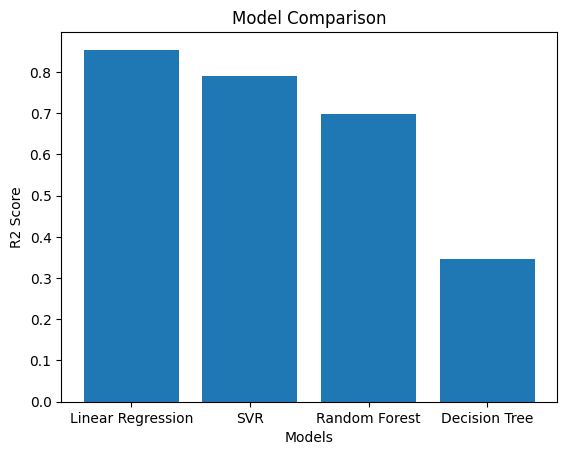


🎯 Best Model Performance:
Model: Linear Regression
MAE: 0.88
RMSE: 1.11
R2 Score: 0.85


In [5]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2 Score"])
# sort by best performance
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\n📊 Model Comparison:\n")
print(results_df)

# Graph
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

# Best model
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

# Get best model predictions again
y_pred_best = best_model.predict(X_test)

# Calculate only best model metrics
best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2 = r2_score(y_test, y_pred_best)

print("\n🎯 Best Model Performance:")
print("Model:", best_model_name)
print("MAE:", round(best_mae, 2))
print("RMSE:", round(best_rmse, 2))
print("R2 Score:", round(best_r2, 2))

In [7]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("\nCross Validation R2 Scores:", cv_scores)
print("Average CV Score:", round(cv_scores.mean(), 2))


print("\nHi there! 😊")
print("Let's personalize your study plan!\n")

rating_map = {
    "very bad": 1,
    "bad": 3,
    "average": 5,
    "good": 7,
    "very good": 9
}

def get_input(question):
    val = input(question + " (very bad / bad / average / good / very good): ").lower()
    return rating_map.get(val, 5)

# Numeric inputs
difficulty = int(input("How difficult is your topic? (1-10): "))
past_hours = int(input("How many hours have you already studied? "))
sleep = int(input("How many hours did you sleep? "))

# Categorical inputs
focus = get_input("How focused are you feeling?")
familiarity = get_input("How familiar are you with the topic?")
energy = get_input("Your energy level?")
distractions = get_input("Distractions around you?")
consistency = get_input("Your consistency?")

# NEW FEATURE
subject_type = input("\nSubject type (logical / memorization / creative): ").lower()


# prediction
user_input = pd.DataFrame([{
    "difficulty": difficulty,
    "past_hours": past_hours,
    "sleep": sleep,
    "focus": focus,
    "familiarity": familiarity,
    "energy": energy,
    "distractions": distractions,
    "consistency": consistency
}])

prediction = best_model.predict(user_input)

# Step 1: Scale down the raw ML prediction to a realistic range
# ML model was trained on formula values (can go up to 12+)
# Real study sessions: 1.5 to 5 hours
study_time = round(prediction[0], 1)

# Normalize to 0–1 scale (assuming model outputs roughly 2–12)
normalized = (study_time - 2) / (12 - 2)
normalized = max(0, min(1, normalized))  # clamp between 0 and 1

# Map to realistic range: 1.5 hours (easy) to 5 hours (very hard)
study_time = 1.5 + normalized * 3.5  # range: 1.5 → 5.0 hours

# Step 2: Fine-tune based on context (small nudges only)
if focus >= 7 and energy >= 7:
    study_time -= 1.5

if familiarity >= 6:
    study_time -= 1

if sleep >= 7:
    study_time -= 0.8

if distractions >= 7:
    study_time += 1

if consistency <= 4:
    study_time += 0.5

# Bound values
study_time = max(2, min(8, study_time))
study_time = round(study_time, 1)


# ==============================
# POMODORO BREAKDOWN
# ==============================

if subject_type == "logical":
    session = 50
    break_time = 10
    strategy = "Deep work sessions for problem solving 🧠"

elif subject_type == "memorization":
    session = 25
    break_time = 5
    strategy = "Short bursts + repetition 🧠"

else:
    session = 40
    break_time = 10
    strategy = "Creative flexible sessions 🎨"

total_minutes = study_time * 60
sessions = int(total_minutes // session)

leftover = total_minutes % session

# 🍅 Pomodoro Breakdown:
#    That's approximately 3 Pomodoro sessions (25 min each)
#    + ~15 extra minutes of lighter review
#    Remember to take a 5-min break after each session! ☕
#    Every 4 sessions → take a longer 15–20 min break 🛋️


# ==============================
# 9. SUGGESTIONS
# ==============================
suggestions = []
suggestions = []

if distractions > 7:
    suggestions.append("Your environment seems distracting 📵. Try studying in a quieter place or keep your phone away.")
    suggestions.append("You can also use techniques like 'focus mode' or apps that block notifications.")

if sleep < 6:
    suggestions.append("You are getting less sleep 😴, which directly affects memory and focus.")
    suggestions.append("Try to rest properly before long study sessions for better efficiency.")

if focus < 5:
    suggestions.append("Your focus level is low 🧘. Try Pomodoro technique or short meditation.")
    suggestions.append("Start with small, easy tasks to build momentum and concentration.")

if energy < 5:
    suggestions.append("Low energy ⚡ can slow you down.")
    suggestions.append("Take a short break, drink water, or have a light snack before continuing.")

if familiarity < 4:
    suggestions.append("You are not very familiar with the topic 📘.")
    suggestions.append("Start with basics, watch a short video, or revise concepts first.")

if consistency < 5:
    suggestions.append("Your consistency is low 📅.")
    suggestions.append("Try studying at the same time daily to build a strong habit.")

if len(suggestions) == 0:
    suggestions.append("Everything looks balanced 👍. You’re in a great state to study efficiently!")
    suggestions.append("Maintain this routine and aim for steady improvement 🚀")

# Effort calculation (simple logic)
effort = ((focus + consistency + energy) / 30) * 100
effort = round(effort, 1)    


# ==============================
# 10. OUTPUT
# ==============================
print("\n📚 Based on your inputs:")
print("\n" + "="*50)
print("📚 STUDY PLAN SUMMARY")
print("="*50)

print(f"\n⏱ Estimated Study Time: {study_time} hours")

# Effort Level First (better flow)
print(f"\n📊 Effort Level: {effort}%")

if effort >= 85:
    print("🔥 Outstanding! You're in peak condition!")
elif effort >= 70:
    print("💪 Strong effort! You're on the right track!")
elif effort >= 50:
    print("👍 Decent effort, but you can push more!")
elif effort >= 30:
    print("⚠️ Low effort — try improving focus & consistency")
else:
    print("🚨 Very low effort — reset your routine and start fresh!")

# =========================
# PERSONALIZED PLAN
# =========================
print("\n📌 Your Personalized Study Plan:")
print("-"*50)

print(f"🧠 Strategy: {strategy}")
print(f"🍅 Pomodoro: {session} min study + {break_time} min break")
print(f"🔁 Total Sessions: {sessions}")

if leftover > 0:
    print(f"⏳ Extra Revision Time: {round(leftover,1)} minutes")

# =========================
# SUGGESTIONS
# =========================
print("\n💡 Smart Suggestions for You:")
for s in suggestions:
    print("✔", s)

# =========================
# MINI WELLNESS TOUCH 🌸
# =========================
# print("\n🌸 Quick Boost Ideas:")
# print("• Listen to 5-min music 🎧")
# print("• Wash your face 💧")
# print("• Talk to someone you like ❤️")
# print("• Have a small snack 🍎")

# =========================
# WHY THIS RESULT
# =========================
print("\n🧠 Why this result?")
reasons = []

if difficulty > 7:
    reasons.append("The topic is highly difficult, so it naturally requires more time and deeper understanding.")

if focus < 5:
    reasons.append("Your focus level is low, meaning tasks may take longer to complete.")

if familiarity < 5:
    reasons.append("You are not very familiar with the topic, so extra time is needed for revision and understanding.")

if distractions > 7:
    reasons.append("High distractions reduce efficiency, increasing the total study time required.")

if sleep < 6:
    reasons.append("Lack of proper sleep affects concentration and memory retention.")

if energy < 5:
    reasons.append("Low energy levels can slow down your learning speed.")

if consistency < 5:
    reasons.append("Inconsistent study habits reduce overall efficiency and require more effort.")

if len(reasons) == 0:
    print("All your inputs are balanced, so you can study efficiently in less time 👍")
else:
    for r in reasons:
        print("•", r)

print("\n" + "="*50)
print("✨ Stay consistent — small progress daily = big success!")
print("="*50)  


Cross Validation R2 Scores: [0.8502832  0.87463226 0.89022604 0.85814475 0.83115085]
Average CV Score: 0.86

Hi there! 😊
Let's personalize your study plan!



How difficult is your topic? (1-10):  10
How many hours have you already studied?  5
How many hours did you sleep?  4
How focused are you feeling? (very bad / bad / average / good / very good):  bad
How familiar are you with the topic? (very bad / bad / average / good / very good):  good
Your energy level? (very bad / bad / average / good / very good):  bad
Distractions around you? (very bad / bad / average / good / very good):  very good
Your consistency? (very bad / bad / average / good / very good):  bad

Subject type (logical / memorization / creative):  logical



📚 Based on your inputs:

📚 STUDY PLAN SUMMARY

⏱ Estimated Study Time: 3.3 hours

📊 Effort Level: 30.0%
⚠️ Low effort — try improving focus & consistency

📌 Your Personalized Study Plan:
--------------------------------------------------
🧠 Strategy: Deep work sessions for problem solving 🧠
🍅 Pomodoro: 50 min study + 10 min break
🔁 Total Sessions: 3
⏳ Extra Revision Time: 48.0 minutes

💡 Smart Suggestions for You:
✔ Your environment seems distracting 📵. Try studying in a quieter place or keep your phone away.
✔ You can also use techniques like 'focus mode' or apps that block notifications.
✔ You are getting less sleep 😴, which directly affects memory and focus.
✔ Try to rest properly before long study sessions for better efficiency.
✔ Your focus level is low 🧘. Try Pomodoro technique or short meditation.
✔ Start with small, easy tasks to build momentum and concentration.
✔ Low energy ⚡ can slow you down.
✔ Take a short break, drink water, or have a light snack before continuing.
✔ Your